# EEE3027 Embedded Systems Coursework  Preliminary

In this semester's coursework, you will be creating a software-based embedded system using Python, where you will implement an optimal first-in first-out (FIFO) buffer with shared memory capabilities (via a mutual exclusion (MUTEX) protocol) leading to a real-time forecasting application (with parallel processes) using machine learning (ML) models. 

This notebook serves as an example ML pipeline that is complete sequential, which you will work on and improve. The ML model of choice is the **Long Short-Term Memory (LSTM) Recurrent Neural Network (RNN)**.

> **_NOTE:_** Because this is not an ML course, and so therefore we are not expecting you to become ML experts. This example is purely only for the coursework and will not be in the exams. But, for interested students who wish to learn more about LSTMs and want to dive deep into the world of ML, we encourage you to read the [original LSTM paper](https://ieeexplore.ieee.org/abstract/document/6795963) or take a look at [Colah's blog on LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/).

# A very simple illustration of how ML models work

For this coursework, you can simply view the ML model as just another 'black box' tool that you feed data into to produce some output, where the output maybe non-deterministic and is driven by the provided data given, hyperparameters and its training procedure. Typically, data contains features (i.e. the properties/characteristics) and its labels (i.e. the actual values associated to these properties/characteristics). 

The idea is that these ML models will go through some extensive training and learn from the data, before it *hopefully* produces the desired outcome when it is inferred. To help illustrate this, the figure below shows a very 'naive' view of how data is fed into an ML model (e.g. say our LSTM RNN) which is then trained sufficiently until we get a 'finalised' ML model that we use to infer and produce results. 

![Diagram that shows a very simplistic overview of how an ML model is trained, where some data is given and the model is then trained to eventually produce some result.](training.svg)

# LSTM Bitesize

LSTM is a type of RNN that aims to mitigate the vanishing gradient problem, which is common for vanilla RNNs. The 'vanishing gradient problem' is the idea that RNN's the gradients become so small that it no longer updates the *weights* sufficiently, which can lead to loss of 'memory'. 

The way that LSTM addresses this is by improving the architecture in such a way where there is not only have a working memory (i.e. short-term memory) but also a carry-on memory (i.e. long-term memory). 

## LSTM Characteristics

In an LSTM, there are three key gates: 

1. The Forget Gate manages what should be forgotten.
2. The Input Gate manages what should be kept, and
3. The Output Gate manages what information is stored in the carry and hidden states.

Each of these gates comprise of their own neural network layer that handles the mathematics needed to retain the relevant data we need to store in both the short-term memory and long-term memory. (If you wish to find out more, I highly recommend [Colah's blog on LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/).

Just as another 'naive' example, the structure of an LSTM is illustrated in the diagram below.

![A diagram depicting the structure of an LSTM cell](lstm-cell.svg)

## How does the LSTM work? 

To summarise: LSTM is just a special type of RNN - Like how recursive functions typically work, our LSTM 'recursively' handles all the data provided until the last datapoint is reached (leading to a completion of one epoch). 

In fact, when we look at how RNNs/LSTMs are structured, we can view the RNN/LSTM as a singular cell that consist of the previous carry state, previous hidden state and data as its input and the next carry state and next hidden state as its output, which is directly fed back into the LSTM as part of its input. This can lead to this 'folded' structure illustrated in the diagram below on the left. 

Now, if we 'unfold' this structure as illustrated in the diagram below on the right, we can 'break up' our LSTM up to **_n_** separate processes that occur at each (time) step. This leads to what we call an 'unfolded' structure.

![A diagram depicting both the folded and unfolded structure of an LSTM archtecture](lstm-architecture.svg)

# Objectives

From this example, you will (hopefully)...

- ...gain an idea how to begin building an ML model (more specifically, the LSTM) from loading and preprocessing the data to training and infering the ML model.
- 
- ...start to identify the different components that are typically used within an ML implementation, which you will need to eventually break it down into separate concurrent processes.

# Prerequisites

In order to complete this tutorial, you will need to install the following libraries if you have not done so already. 

> **_NOTE:_** These installation instructions assume that you *do not* have any of the libraries installed (including Jupyter Notebook since you can technically open it through Visual Studio Code) and plan to install it through a separate Python environment (as it is usually a good idea to create separate Python environments for different works).
>
> The following instructions *should* work for both Linux and MacOS environments, with some alterations for the Windows environment.

```bash
mkdir labs 
cd labs 
python3 -m venv LAB_ENVIRONMENT
source LAB_ENVIRONMENT/bin/activate
pip3 install -r requirements.txt
```

Run this separately as pyTorch has some funky dependencies...
```bash
pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```

If you're a Mac user and/or don't have a GPU, don't include the --index-url, i.e. run below:
```bash
pip3 install torch torchvision.
```

Alternatively, you can install the libraries individually, e.g.:
```bash
pip3 install notebook numpy pandas seaborn scikit-learn torch torchvision --index-url https://download.pytorch.org/whl/cu126
```

With the setup above, you want to run the notebook by going to this ```labs``` directory and type in: ```source LAB_ENVIRONMENT/bin/activate```. 

## 1. Import the necessary libraries. 

Like in your previous exercises, you can simply import the libraries like below.

> **_NOTE:_** Remember that you need to install the libraries above or none of the below will work.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## 2. Configure the implementation to execute on either the CPU or the GPU.

Generally, it is *faster* to run your implementation(s) on the GPU rather than the CPU. By default, your implementation(s) will always run on the CPU unless you tell it otherwise. 

If your machine has a decent/good GPU available e.g. say an NVidia XX60+ card or an AMD X600+ card series, then you may want to run your implementation on the GPU and leverage of the GPU training benefits. 

**However, please do not feel pressured to use the GPU - it is entirely sufficient to use the CPU for the purposes of your coursework. This is only if you wish to train your ML models that bit faster.**

Alternatively, you may use Google collab if all else fails: https://colab.research.google.com/.

Assuming your Pytorch libraries are installed with GPU capabilities, you will be able to run a similar command like below. 

In [2]:
# The command above has been significantly simplified. It checks if you have CUDA, then MPS for Macs and finally the general CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device) # Debugging to check if the device is set up correctly!

mps


## 3. Load and preprocess your data.
For this step, loading the data is extremely simple - But, how this data works with the ML model can be quite tricky. For example, what features are you considering? Which ones are inputs and outputs? How could they be useful for the ML model? How much of the data is necessary? etc. Theoretically, ML models can simply work out-of-the-box with the 'raw' data without any training, but this model will likely be completely useless or perhaps lead to other issues like inaccuracy, overfitting, underfitting, etc. 

The key to ensure that the ML model is actually learning is by properly pre-processing such raw data into a format that can be understood by the ML model and to select what *attributes* we want it to learn. There is not a concrete way for this though - every ML model is different and it is ultimately up to the designer to identify the issues and understand how to resolve them. 

Generally, you want to identify what are your 'features' (i.e. the measurable property/characteristic of a dataset you want to target) and what are your 'labels' (i.e. the actual value related to the feature). Then, pre-process this data (e.g. are there any null values? If so, clean them! Do you need to scale it? Do so!). 

> **_Note:_** Remember this course is not an ML module, so we will not expect you to know what are your features and labels straight away, nor identify what pre-processing steps you will need in order for your ML model to function. This will come in due time as you progress through the remaining weeks and implement your solution. 

## Some details about the dataset

The `weather2010.csv` is a slightly slimmed down `london_weather.csv` file ranging from 2010 to 2020. It contains the following columns:

- **date** - recorded date of measurement - (**int**)
- **cloud_cover** - cloud cover measurement in oktas - (**float**)
- **sunshine** - sunshine measurement in hours (hrs) - (**float**)
- **global_radiation** - irradiance measurement in Watt per square meter (W/m2) - (**float**)
- **max_temp** - maximum temperature recorded in degrees Celsius (°C) - (**float**)
- **mean_temp** - **target** mean temperature in degrees Celsius (°C) - (**float**)
- **min_temp** - minimum temperature recorded in degrees Celsius (°C) - (**float**)
- **precipitation** - precipitation measurement in millimeters (mm) - (**float**)
- **pressure** - pressure measurement in Pascals (Pa) - (**float**)
- **snow_depth** - snow depth measurement in centimeters (cm) - (**float**)


In [3]:
weather = pd.read_csv('weather2010.csv')

In [4]:
weather

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,20100101,2.0,6.4,49.0,5.0,1.6,-0.5,0.0,100560.0,0.0
1,20100102,4.0,5.9,48.0,3.0,1.3,-2.4,0.0,101550.0,0.0
2,20100103,2.0,3.9,39.0,0.9,1.2,-0.6,0.0,102280.0,0.0
3,20100104,0.0,6.3,50.0,2.1,-2.5,-5.8,0.2,101960.0,0.0
4,20100105,7.0,0.1,15.0,1.0,-1.9,-5.9,2.0,100520.0,0.0
...,...,...,...,...,...,...,...,...,...,...
4013,20201227,1.0,0.9,32.0,7.5,7.5,7.6,2.0,98000.0,NaN
4014,20201228,7.0,3.7,38.0,3.6,1.1,-1.3,0.2,97370.0,NaN
4015,20201229,7.0,0.0,21.0,4.1,2.6,1.1,0.0,98830.0,NaN
4016,20201230,6.0,0.4,22.0,5.6,2.7,-0.1,0.0,100200.0,NaN


In [5]:
# Let us first the date
weather['date'] = pd.to_datetime(weather['date'], format='%Y%m%d') # Turn the date string objects into actual datetime objects

In [6]:
weather

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,2010-01-01,2.0,6.4,49.0,5.0,1.6,-0.5,0.0,100560.0,0.0
1,2010-01-02,4.0,5.9,48.0,3.0,1.3,-2.4,0.0,101550.0,0.0
2,2010-01-03,2.0,3.9,39.0,0.9,1.2,-0.6,0.0,102280.0,0.0
3,2010-01-04,0.0,6.3,50.0,2.1,-2.5,-5.8,0.2,101960.0,0.0
4,2010-01-05,7.0,0.1,15.0,1.0,-1.9,-5.9,2.0,100520.0,0.0
...,...,...,...,...,...,...,...,...,...,...
4013,2020-12-27,1.0,0.9,32.0,7.5,7.5,7.6,2.0,98000.0,NaN
4014,2020-12-28,7.0,3.7,38.0,3.6,1.1,-1.3,0.2,97370.0,NaN
4015,2020-12-29,7.0,0.0,21.0,4.1,2.6,1.1,0.0,98830.0,NaN
4016,2020-12-30,6.0,0.4,22.0,5.6,2.7,-0.1,0.0,100200.0,NaN


In [7]:
# Let us assume there are no snow for NaN values in snow depth
weather['snow_depth'] = weather['snow_depth'].fillna(0)

In [8]:
weather

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,2010-01-01,2.0,6.4,49.0,5.0,1.6,-0.5,0.0,100560.0,0.0
1,2010-01-02,4.0,5.9,48.0,3.0,1.3,-2.4,0.0,101550.0,0.0
2,2010-01-03,2.0,3.9,39.0,0.9,1.2,-0.6,0.0,102280.0,0.0
3,2010-01-04,0.0,6.3,50.0,2.1,-2.5,-5.8,0.2,101960.0,0.0
4,2010-01-05,7.0,0.1,15.0,1.0,-1.9,-5.9,2.0,100520.0,0.0
...,...,...,...,...,...,...,...,...,...,...
4013,2020-12-27,1.0,0.9,32.0,7.5,7.5,7.6,2.0,98000.0,0.0
4014,2020-12-28,7.0,3.7,38.0,3.6,1.1,-1.3,0.2,97370.0,0.0
4015,2020-12-29,7.0,0.0,21.0,4.1,2.6,1.1,0.0,98830.0,0.0
4016,2020-12-30,6.0,0.4,22.0,5.6,2.7,-0.1,0.0,100200.0,0.0


In [9]:
# In some cases, you may still have some missing data.
print(weather.isna().sum())                # Count number of NaN values
# print(weather[weather.isna().any(axis=1)]) # Uncomment if you want to see the details

date                0
cloud_cover         3
sunshine            0
global_radiation    6
max_temp            6
mean_temp           7
min_temp            2
precipitation       6
pressure            0
snow_depth          0
dtype: int64


In [10]:
# ...and remove those NaN values
weather.dropna(inplace=True) 
# print(weather.info)
weather.isna().sum()

date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64

## Quick exploratory data analysis (EDA)

We will not cover this in too much detail, but it is generally a good idea to perform some if you're planning to do forecasting

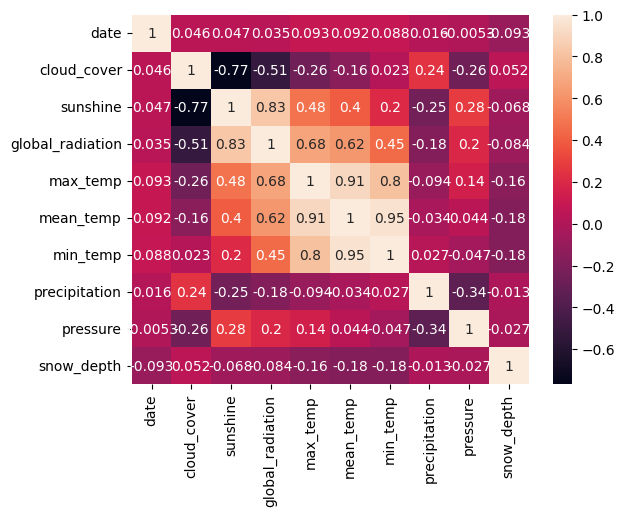

In [11]:
# Let's find out the correlation between features
correlation = weather.corr()
sns.heatmap(correlation, annot=True)
plt.show()

In [12]:
correlation["mean_temp"].sort_values(ascending = False)

mean_temp           1.000000
min_temp            0.952199
max_temp            0.909929
global_radiation    0.621294
sunshine            0.398202
date                0.092061
pressure            0.043994
precipitation      -0.034132
cloud_cover        -0.159484
snow_depth         -0.179782
Name: mean_temp, dtype: float64

<Axes: xlabel='date'>

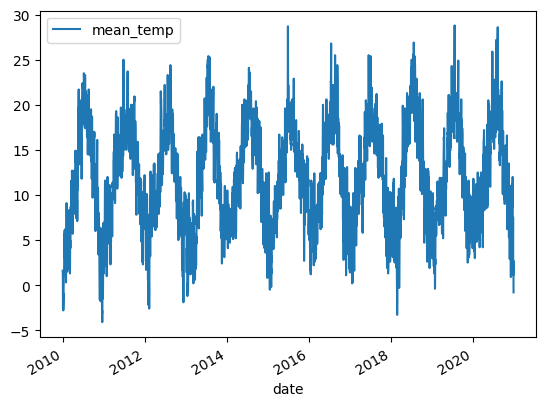

In [13]:
weather.plot(x = "date", y = "mean_temp")

In [14]:
# In some cases, you may want to add extra features where applicable

# Let's add some 1 day lags
weather['mean_temp_lag_1'] = weather['mean_temp'].shift(1)
weather['min_temp_lag_1'] = weather['min_temp'].shift(1)
weather['max_temp_lag_1'] = weather['max_temp'].shift(1)
weather.dropna(inplace=True) # Because lag shifts, you need to delete the introduced NaNs
print(weather)

           date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
1    2010-01-02          4.0       5.9              48.0       3.0        1.3   
2    2010-01-03          2.0       3.9              39.0       0.9        1.2   
3    2010-01-04          0.0       6.3              50.0       2.1       -2.5   
4    2010-01-05          7.0       0.1              15.0       1.0       -1.9   
5    2010-01-06          7.0       0.0              13.0       0.1       -0.9   
...         ...          ...       ...               ...       ...        ...   
4013 2020-12-27          1.0       0.9              32.0       7.5        7.5   
4014 2020-12-28          7.0       3.7              38.0       3.6        1.1   
4015 2020-12-29          7.0       0.0              21.0       4.1        2.6   
4016 2020-12-30          6.0       0.4              22.0       5.6        2.7   
4017 2020-12-31          7.0       1.3              34.0       1.5       -0.8   

      min_temp  precipitati

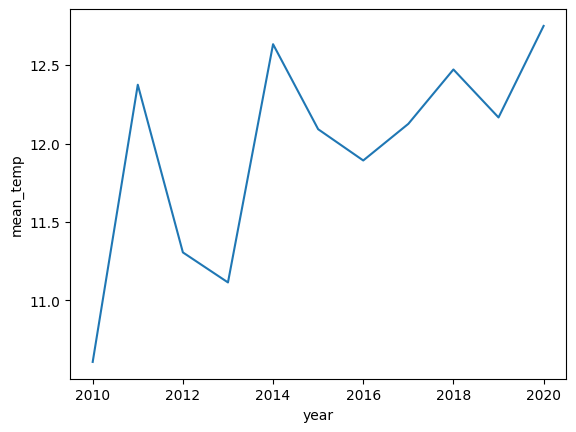

In [15]:
# and some very naive weather information 
weather["year"] = weather["date"].dt.year
weather['month'] = weather['date'].dt.month
weather_metrics = ['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']
weather_per_month = weather.groupby(['year', 'month'], as_index = False)[weather_metrics].mean()

# Let's plot the monthly data, e.g. the mean_temp again
sns.lineplot(x="year", y="mean_temp", data=weather_per_month, ci=None)
plt.show()

In [16]:
# You may even add in some sines and cosines to better 'mimic'/capture the seasonality more
months = weather['date'].dt.month
# Create the cyclical features
weather['month_sin'] = np.sin(2 * np.pi * months / 12)
weather['month_cos'] = np.cos(2 * np.pi * months / 12)
print(weather)

           date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
1    2010-01-02          4.0       5.9              48.0       3.0        1.3   
2    2010-01-03          2.0       3.9              39.0       0.9        1.2   
3    2010-01-04          0.0       6.3              50.0       2.1       -2.5   
4    2010-01-05          7.0       0.1              15.0       1.0       -1.9   
5    2010-01-06          7.0       0.0              13.0       0.1       -0.9   
...         ...          ...       ...               ...       ...        ...   
4013 2020-12-27          1.0       0.9              32.0       7.5        7.5   
4014 2020-12-28          7.0       3.7              38.0       3.6        1.1   
4015 2020-12-29          7.0       0.0              21.0       4.1        2.6   
4016 2020-12-30          6.0       0.4              22.0       5.6        2.7   
4017 2020-12-31          7.0       1.3              34.0       1.5       -0.8   

      min_temp  precipitati

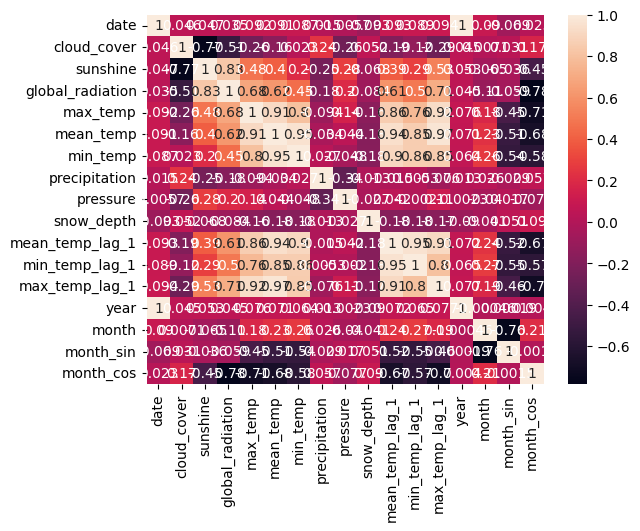

mean_temp           1.000000
max_temp_lag_1      0.965776
min_temp            0.952169
mean_temp_lag_1     0.937542
max_temp            0.909864
min_temp_lag_1      0.854782
global_radiation    0.621245
sunshine            0.398627
month               0.228924
date                0.091348
year                0.070917
pressure            0.043600
precipitation      -0.034354
cloud_cover        -0.160130
snow_depth         -0.179893
month_sin          -0.512996
month_cos          -0.676437
Name: mean_temp, dtype: float64

In [17]:
# and for good measure, let's see how big/awful our correlation is
sns.heatmap(weather.corr(), annot=True)
plt.show()

weather.corr()["mean_temp"].sort_values(ascending = False)

## 4. Splitting the input/target data into a training set and a testing set.

In order for the ML model to actually learn from your given data, you will also need to validate it against the data itself. However, simply feeding the whole data as both the training and testing data into the ML model is incorrect as they can lead to the ML model being overfitted and/or learning the patterns specifically tied to the data (meaning it will likely underperform when you introduce new data). 

To avoid this, you will need to split the data into an appropriate ratio of training data and testing data. For our purposes, a 80/20 split will be sufficient. 

In [18]:
## Let's choose some features
## There are lots of ways to do this but in our example, we'll just select them
# input_data = weather.drop(['date', 'mean_temp', 'min_temp', 'max_temp'], axis=1)
# print(input_data)
# targets = weather['mean_temp'].values
# print(targets)

# input_features = ['min_temp_lag_1', 'max_temp_lag_1', 'mean_temp_lag_1', 'cloud_cover', 'sunshine', 'global_radiation', 'pressure', 'month_sin', 'month_cos']
input_features = ['min_temp_lag_1', 'max_temp_lag_1', 'mean_temp_lag_1', 'cloud_cover', 'sunshine', 'global_radiation', 'pressure', 'month_sin', 'month_cos']
target_feature = 'mean_temp'

input_data = weather[input_features]
print(input_data)

target = weather[target_feature]
print(target)

      min_temp_lag_1  max_temp_lag_1  mean_temp_lag_1  cloud_cover  sunshine  \
1               -0.5             5.0              1.6          4.0       5.9   
2               -2.4             3.0              1.3          2.0       3.9   
3               -0.6             0.9              1.2          0.0       6.3   
4               -5.8             2.1             -2.5          7.0       0.1   
5               -5.9             1.0             -1.9          7.0       0.0   
...              ...             ...              ...          ...       ...   
4013             0.7             4.6              2.6          1.0       0.9   
4014             7.6             7.5              7.5          7.0       3.7   
4015            -1.3             3.6              1.1          7.0       0.0   
4016             1.1             4.1              2.6          6.0       0.4   
4017            -0.1             5.6              2.7          7.0       1.3   

      global_radiation  pressure     mo

In [19]:
# Let us flatten the inputs and targets
input_data = input_data.values
target = target.values

In [20]:
input_days = 30
forecast_horizon = 7                    #Number of timesteps to look while predicting
inputs = input_data.shape[1]   #Dimensionality of the input
remaining_data = len(input_data) - forecast_horizon
print(f'Dimensions are {forecast_horizon} × {inputs} × {remaining_data}')

Dimensions are 7 × 9 × 3992


In [21]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

training_split = 0.7

# Fit on the first 70-80% of the data and transform everything else
train_limit = int(len(input_data) * training_split)

feature_scaler.fit(input_data[:train_limit])
target_scaler.fit(target[:train_limit].reshape(-1, 1)) # Reshape target to 2D (N, 1) because sklearn requires 2D inputs

scaled_input = feature_scaler.transform(input_data)
scaled_targets = target_scaler.transform(target.reshape(-1, 1))

In [22]:
# Create Windows from the scaled data
N_adjusted = len(scaled_input) - input_days
X = np.zeros((N_adjusted, input_days, inputs))
y = np.zeros((N_adjusted, forecast_horizon)) 

# 2. Slice a range for the target
for t in range(len(scaled_input) - input_days - (forecast_horizon - 1)):
    X[t, :, :] = scaled_input[t:t+input_days]
    y[t, :] = scaled_targets[t+input_days : t+input_days+forecast_horizon].flatten() # Next 7 days
    

In [23]:
# Split the windowed data into Train/Test - This ensures a clean break in time
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

In [24]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3175, 30, 9)
(3175, 7)
(794, 30, 9)
(794, 7)


In [25]:
# Make inputs and targets
X_train = torch.from_numpy(X_train.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

## 5. Creating the LSTM model 

With our training and testing data now properly prepared, we can now begin implementing our LSTM model. But, before we continue, let us briefly return to technical side and understand what is an LSTM, how it works, and its structure. 

The code below shows how we can create an instance of a defined LSTM class and its parameters, which we will use to build our LSTMWrapper. To further understand the implementation details of LSTM, we refer you to read [Pytorch's page on LSTMs](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html).

In [26]:
class LSTMWrapper(nn.Module):
  def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
    super(LSTMWrapper, self).__init__()
    self.M = hidden_dim
    self.L = layer_dim

    ## The actual underlying LSTM model
    self.model = nn.LSTM(
        input_size=input_dim,
        hidden_size=hidden_dim,
        num_layers=layer_dim,
        batch_first=True
    ) #batch_first to have (batch_dim, seq_dim, feature_dim)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, X):
    # initial hidden state and cell state
    h0 = torch.zeros(self.L, X.size(0), self.M).to(device)
    c0 = torch.zeros(self.L, X.size(0), self.M).to(device)

    out, (hn, cn) = self.model(X, (h0.detach(), c0.detach()))

    # h(T) at the final time step
    out = self.fc(out[:, -1, :])
    return out

In [27]:
hidden_dim = 128
number_of_layers = 2
no_of_inputs = input_data.shape[1]
no_of_outputs = 1
no_of_lstm_outputs = forecast_horizon * no_of_outputs

model = LSTMWrapper(no_of_inputs, hidden_dim, number_of_layers, no_of_lstm_outputs)
model.to(device)

LSTMWrapper(
  (model): LSTM(9, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=7, bias=True)
)

## 6. Training your LSTM model

Once you have the LSTM model ready, we can now begin the training process! 

First thing you will need to ensure is that the data you are feeding to the ML model must be on the same device as it is trained on, e.g. if you are planning to train your ML model on the GPU then the data must also be sent to the GPU.

In order for your LSTM to actually learn from the input it is given, you will need to add some criteria/metric on how your LSTM performs against the true data value and how it can learn from it. In addition, you will need to set the number of **_epochs_** to indicate how many times you wish your LSTM to see every datapoint of your given data. 

> **_NOTE:_** Loss is often used in the training process to help identify the "best" parameter values for your mL model (e.g. the weights in the LSTM). The loss is what you try to optimize in the training by updating weights, while accuracy is more from an applied perspective.

In [28]:
# move data to GPU
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [29]:
from torch.utils.data import DataLoader, TensorDataset

def train(model, learning_rate, X_train, y_train, X_test, y_test, epochs, batch_size=32, debug=False):
    # Create DataLoaders (this is where SHUFFLING happens)
    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        batch_train_losses = []
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            batch_train_losses.append(loss.item())
        
        # Average loss for the epoch
        train_losses.append(np.mean(batch_train_losses))

        # --- EVALUATION ---
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            t_loss = criterion(test_outputs, y_test)
            test_losses.append(t_loss.item())

        if (epoch + 1) % 10 == 0:
             print(f'Epoch {epoch+1} | Train MSE: {train_losses[-1]:.4f} | Test MSE: {t_loss.item():.4f}')

    return train_losses, test_losses

In [ ]:
train_losses, test_losses = train(model, 0.01, X_train, y_train, X_test, y_test, epochs=200, debug=True)

# train_losses, test_losses = train(model,
#                                     0.01,
#                                     X_train,
#                                     y_train,
#                                     X_test,
#                                     y_test,
#                                     epochs=200)

Epoch 10 | Train MSE: 0.1244 | Test MSE: 0.3237
Epoch 20 | Train MSE: 0.0173 | Test MSE: 0.3322
Epoch 30 | Train MSE: 0.0047 | Test MSE: 0.3193
Epoch 40 | Train MSE: 0.0156 | Test MSE: 0.3240
Epoch 50 | Train MSE: 0.0020 | Test MSE: 0.3446
Epoch 60 | Train MSE: 0.0021 | Test MSE: 0.3332
Epoch 70 | Train MSE: 0.0027 | Test MSE: 0.3296
Epoch 80 | Train MSE: 0.0077 | Test MSE: 0.3362


In [ ]:
torch.save(model, "lstm_output/LSTM.pt")                      # Save the LSTM model architecture
torch.save(model.state_dict(), "lstm_output/LSTM_weights.pt") # Save the actual weights trained on the LSTM

## 7. Inferring and Plotting your results - Analysis

After your LSTM has been trained, you can then begin the analytical work of your LSTM model. There are many approaches you can take, but most commonly you analyse the ML model's performance by reading the values of your loss and/or plotting on the graph.

If the performance is acceptable, you can then begin to infer the trained ML model to gather results to be plotted on to a graph to visualise it against the real data. 

In the case of our LSTM example, we will check the losses in both training and testing, followed by inferring the ML model by feeding it the whole data (in sufficient segments) to generate the forecast within the appropriate range. We will take a closer look to our final result by analysing specific periods, before concluding the LSTM implementation details by calculating the distributed errors.

In [ ]:
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('epoch no')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
#Checking one-step prediction performance of the model
test_target = y_test.cpu().detach().numpy()
test_predictions = []

for i in range(len(test_target)):
  input_ = X_test[i].reshape(1, input_days, inputs)
  p = model(input_)[0,0].item()

  # update the predictions list
  test_predictions.append(p)

In [ ]:
real_test_predictions = target_scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
plot_len = len(test_predictions)
plot_df = weather[['date', 'mean_temp']].copy(deep=True)
plot_df = plot_df.iloc[-plot_len:]
plot_df['prediction'] = real_test_predictions
plot_df.set_index('date', inplace=True)
plot_df.head(5)

In [ ]:
plt.rcParams['figure.figsize'] = (25.0, 10.0)
plt.plot(plot_df['mean_temp'], label='Actual Temperature', linewidth=1)
plt.plot(plot_df['prediction'], label='One-step Prediction', linewidth=1)
plt.xlabel('date')
plt.ylabel('temperature (degrees Celcius)')
plt.legend(loc='lower right')

In [ ]:
import random
random.seed(42)
no_of_frames_to_display = 10
random_frames = [random.randint(0, len(X_test) - 1)  for _ in range(no_of_frames_to_display)]
print(random_frames)

In [ ]:
print(X_test.shape)
print(y_test.shape)
for i in random_frames:
    print(y_test[i].detach().cpu())
    # print(X_test[i].shape)
    # print(X_test[i].reshape(1, X_test[i].shape[0], X_test[i].shape[1]).shape)
    p = model(X_test[i].reshape(1, X_test[i].shape[0], X_test[i].shape[1]))
    print("p", p)
    plt.plot(y_test[i].detach().cpu(), label='Actual Temperature', linewidth=1)
    plt.plot(p.cpu().detach().numpy().reshape(-1), label=f'LSTM prediction of {forecast_horizon} days', linewidth=1)
    plt.xlabel('Date / Step')
    plt.ylabel('Temperature (degrees Celcius)')
    plt.legend(loc='lower right')
    plt.show()

In [ ]:
plot_df.index.year.unique()

In [ ]:
plot_df_by_years = []
for y in plot_df.index.year.unique():
    plot_df_by_years += [(y, plot_df.loc[(plot_df.index.year == y)])]

In [ ]:
plot_df_by_years

In [ ]:
for pdfby in plot_df_by_years:
    plt.rcParams['figure.figsize'] = (25.0, 10.0)
    plt.plot(pdfby[1]['mean_temp'], label='Actual Temperature', linewidth=1)
    plt.plot(pdfby[1]['prediction'], label='One-step Prediction', linewidth=1)
    plt.xlabel('date')
    plt.ylabel('temperature (degrees Celcius)')
    plt.legend(loc='lower right')
    plt.title(pdfby[0])
    plt.show()